<a href="https://colab.research.google.com/github/Rrivn/Algorithmization-and-data-visualization/blob/main/%D0%92%D0%B8%D0%B7%D1%83%D0%B0%D0%BB%D0%B8%D0%B7%D0%B0%D1%86%D0%B8%D1%8F_%D1%81_Seaborn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Визуализация с Seaborn

Seaborn против Matplotlib
Вот пример простого графика случайного блуждания в Matplotlib, использующего его классическое форматирование и цвета. Начнем с типичного импорта:

In [ ]:
import matplotlib.pyplot as plt# Импортируем модуль pyplot из библиотеки Matplotlib для работы с графиками
plt.style.use('classic')# Устанавливаем классический стиль для графиков
%matplotlib inline # Используем в Jupyter Notebook для отображения графиков в ячейках
import numpy as np # Импортируем библиотеку NumPy для работы с массивами и математическими функциями
import pandas as pd # Импортируем библиотеку Pandas для работы с данными в формате таблиц (DataFrame)

Теперь создадим некоторые случайные данные:



In [ ]:
# Create some data
rng = np.random.RandomState(0)# Инициализируем генератор случайных чисел с фиксированным семенем для воспроизводимости
x = np.linspace(0, 10, 500) # Генерируем 500 равномерно распределенных значений от 0 до 10
y = np.cumsum(rng.randn(500, 6), 0) # Генерируем 500 случайных чисел (6 столбцов) и накапливаем их сумму по строкам

И сделаем простой график:

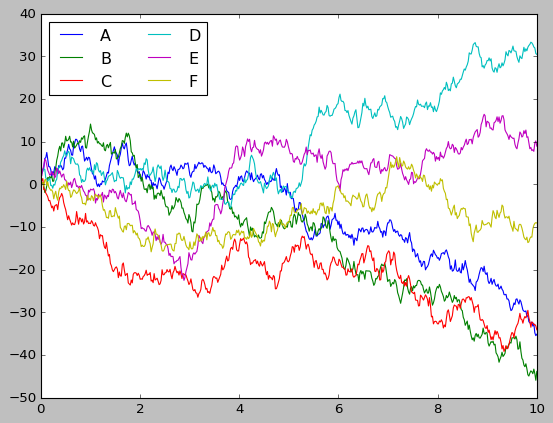

In [ ]:
# Plot the data with Matplotlib defaults# Строим график данных с использованием стандартных настроек Matplotlib
plt.plot(x, y) # Строим линии графика, где 'x' — значения по оси X, а 'y' — значения по оси Y
plt.legend('ABCDEF', ncol=2, loc='upper left'); # Создаем легенду с метками 'A', 'B', 'C', 'D', 'E', 'F',
                                                # располагаем в верхнем левом углу и используем 2 столбца

Хотя результат содержит всю информацию, которую мы хотели бы передать, он сделан не слишком эстетично и даже выглядит немного старомодно в контексте визуализации данных XXI века.

Теперь давайте посмотрим, как это работает с Seaborn. Как мы увидим, Seaborn имеет много собственных высокоуровневых процедур построения графиков, но он также может перезаписывать параметры Matplotlib по умолчанию и, в свою очередь, заставлять даже простые скрипты Matplotlib выдавать значительно более качественный вывод. Мы можем задать стиль, вызвав set()метод Seaborn. По соглашению Seaborn импортируется как sns:

In [ ]:
import seaborn as sns# Импортируем библиотеку Seaborn для визуализации данных, используя псевдоним 'sns'
sns.set()# Устанавливаем стандартные параметры оформления графиков Seaborn для улучшенного визуального восприятия

Теперь давайте повторим те же две строки, что и раньше:

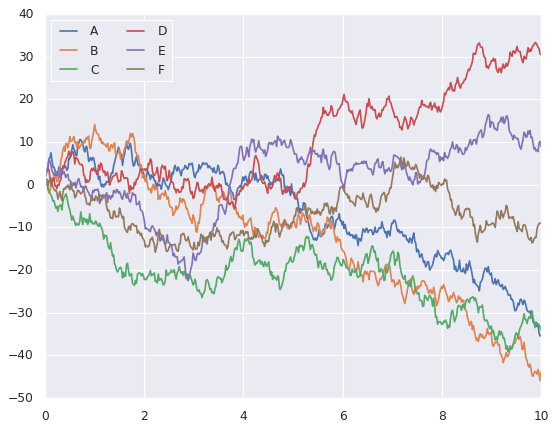

In [ ]:
# same plotting code as above!# То же самое код для построения графика, что и выше!
plt.plot(x, y)# Строим линии графика, где 'x' — значения по оси X, а 'y' — значения по оси Y
plt.legend('ABCDEF', ncol=2, loc='upper left'); # Создаем легенду с метками 'A', 'B', 'C', 'D', 'E', 'F',
                                                # располагаем в верхнем левом углу и используем 2 столбца

**Гистограммы, KDE и плотности**

Часто при визуализации статистических данных все, что вам нужно, это построить гистограммы и совместные распределения переменных. Мы увидели, что это относительно просто в Matplotlib:

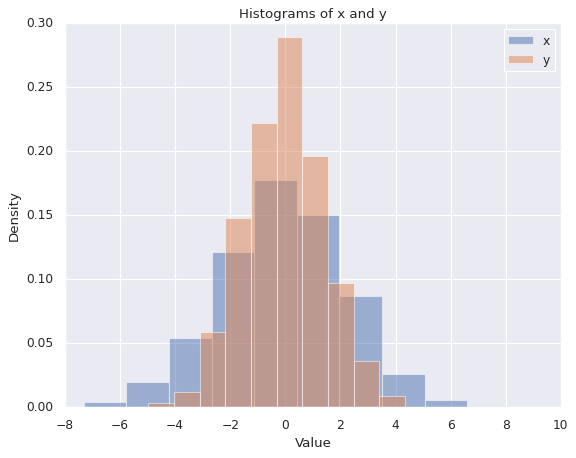

In [ ]:
import numpy as np # Импортируем библиотеку NumPy для работы с числовыми массивами и генерацией случайных данных
import pandas as pd# Импортируем библиотеку Pandas для обработки и анализа данных в формате таблиц DataFrame
import matplotlib.pyplot as plt# Импортируем библиотеку Matplotlib для визуализации данных

# Генерация данных
data = np.random.multivariate_normal([0, 0], [[5, 2], [2, 2]], size=2000)# Генерируем 2000 точек двумерного нормально распределенного шума с заданным средним и ковариационной матрицей
data = pd.DataFrame(data, columns=['x', 'y'])# Преобразуем сгенерированные данные в DataFrame с колонками 'x' и 'y'

# Построение гистограмм
for col in 'xy': # Итерация по колонкам 'x' и 'y'
    plt.hist(data[col], density=True, alpha=0.5)  # Заменили `normed=True` на `density=True`
# Строим гистограмму для каждого столбца,
                                                  # нормируем по плотности (density=True)
                                                  # и устанавливаем прозрачность (alpha=0.5)
plt.legend(['x', 'y'])# Добавляем легенду для обозначения гистограмм 'x' и 'y'
plt.xlabel('Value')# Подписываем ось X
plt.ylabel('Density')# Подписываем ось Y
plt.title('Histograms of x and y')# Добавляем заголовок графика
plt.show()# Отображаем график

Вместо гистограммы мы можем получить сглаженную оценку распределения, используя оценку плотности ядра, которую Сиборн делает с помощью sns.kdeplot:

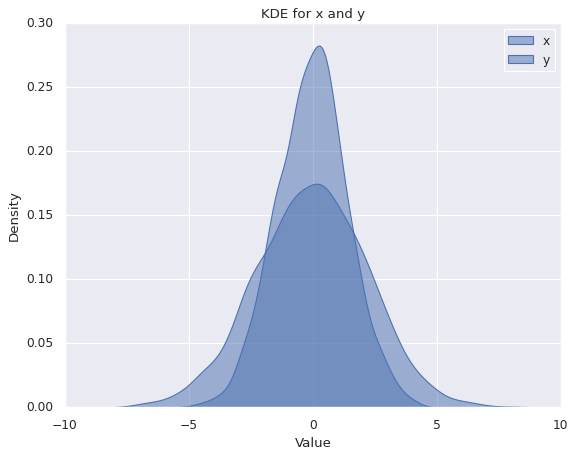

In [ ]:
import seaborn as sns # Импортируем библиотеку Seaborn для визуализации данных с легким доступом к статистическим графикам
import matplotlib.pyplot as plt # Импортируем библиотеку Matplotlib для построения графиков

# Построение KDE (оценки плотности вероятности) для 'x' и 'y'
for col in 'xy': # Итерация по колонкам 'x' и 'y'
    sns.kdeplot(data[col], fill=True, alpha=0.5, label=col)
# Построение графика KDE для текущего столбца,
    # с заливкой (fill=True), устанавливаем прозрачность (alpha=0.5)
    # и добавляем метку для легенды (label=col)

plt.legend()# Отображаем легенду на графике
plt.xlabel('Value') # Подписываем ось X
plt.ylabel('Density')# Подписываем ось Y
plt.title('KDE for x and y')# Добавляем заголовок графика
plt.show()# Отображаем график

Гистограммы и KDE можно объединить с помощью distplot:

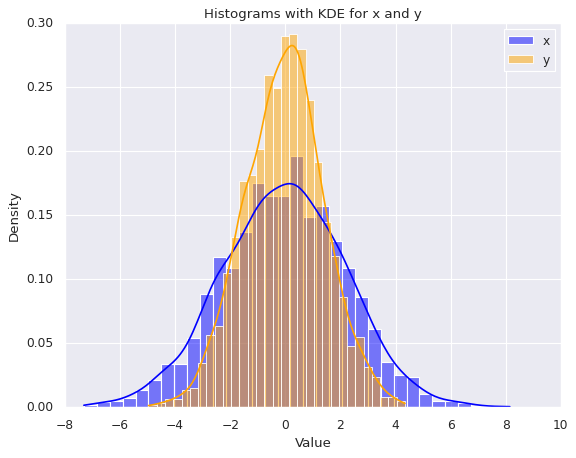

In [ ]:
import seaborn as sns# Импортируем библиотеку Seaborn для простоты визуализации данных
import matplotlib.pyplot as plt # Импортируем библиотеку Matplotlib для построения графиков

# Построение гистограмм для 'x' и 'y' с KDE (оценкой плотности вероятности)
sns.histplot(data['x'], kde=True, stat='density', color='blue', label='x', alpha=0.5)
# Строим гистограмму для колонки 'x', добавляем оценку плотности (kde=True),
# нормируем по плотности (stat='density'), задаем цвет (color='blue'),
# устанавливаем метку для легенды (label='x') и задаем прозрачность (alpha=0.5)
sns.histplot(data['y'], kde=True, stat='density', color='orange', label='y', alpha=0.5)
# Строим гистограмму для колонки 'y' с аналогичными параметрами, но с другим цветом и меткой
plt.legend()# Отображаем легенду на графике для обозначения 'x' и 'y'
plt.xlabel('Value')# Подписываем ось X
plt.ylabel('Density')# Подписываем ось Y
plt.title('Histograms with KDE for x and y')# Добавляем заголовок графика
plt.show()  # Отображаем график
plt.show()# Отображаем график

Если мы передадим полный двумерный набор данных в kdeplot, мы получим двумерную визуализацию данных:

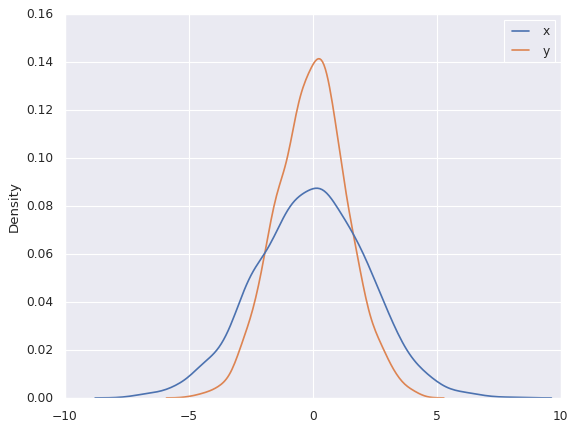

In [ ]:
sns.kdeplot(data);

Мы можем увидеть совместное распределение и маргинальные распределения вместе, используя sns.jointplot. Для этого графика мы установим стиль на белый фон:

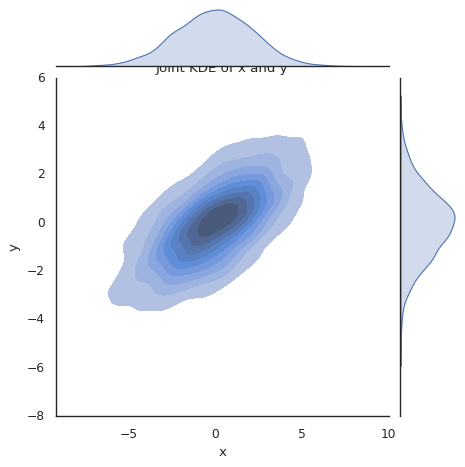

In [ ]:
import seaborn as sns# Импортируем библиотеку Seaborn для визуализации данных
import matplotlib.pyplot as plt# Импортируем библиотеку Matplotlib для построения графиков

# Установка стиля графика
with sns.axes_style('white'): # Устанавливаем стиль графика на 'white' (белый фон)
    # Построение графика совместного распределения с KDE
    sns.jointplot(x="x", y="y", data=data, kind='kde', fill=True)
 # Создаем график, показывающий совместное распределение 'x' и 'y'
    # с оценкой плотности (kind='kde') и заполнением (fill=True)
plt.title('Joint KDE of x and y') # Добавляем заголовок графика
plt.show()# Отображаем график

**Парные участки**

При обобщении совместных графиков на наборы данных большего размера вы получаете парные графики . Это очень полезно для изучения корреляций между многомерными данными, когда вы хотите построить график всех пар значений относительно друг друга.

Мы продемонстрируем это на примере известного набора данных Iris, в котором приведены размеры лепестков и чашелистиков трех видов ирисов:

In [ ]:
iris = sns.load_dataset("iris")# Загружаем встроенный набор данных "iris" с помощью Seaborn, который содержит информацию о различных видах ирисов
iris.head()# Отображаем первые несколько строк загруженного DataFrame для быстрого просмотра данных

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


Визуализировать многомерные отношения между образцами так же просто, как вызвать sns.pairplot:

/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:2100: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


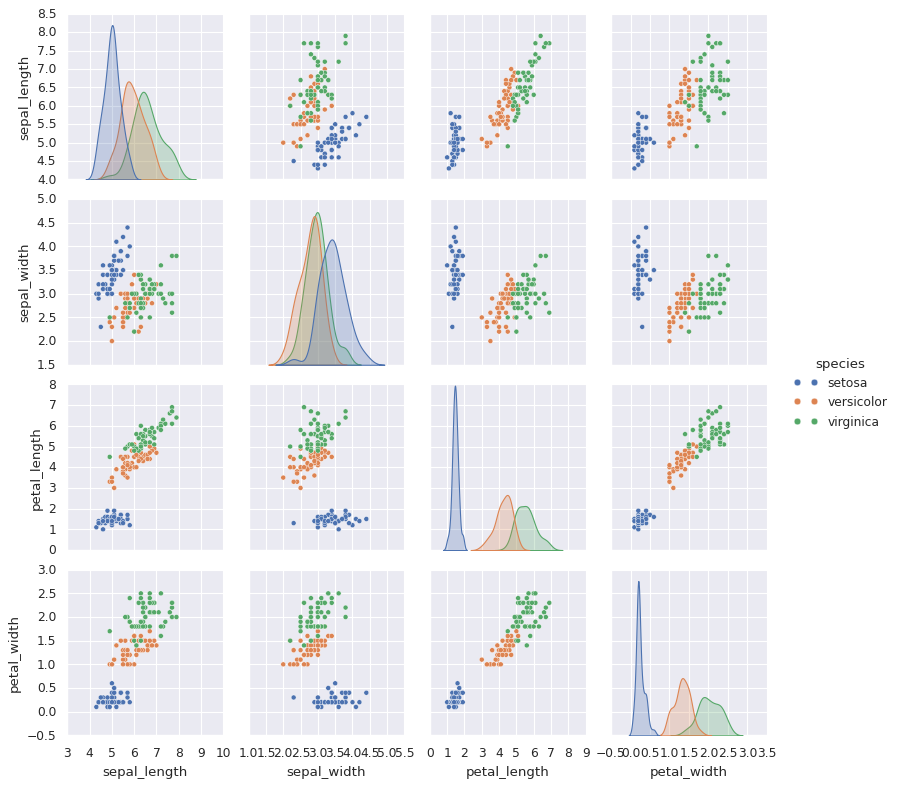

In [ ]:
sns.pairplot(iris, hue='species', size=2.5);
# Создаем матрицу парных графиков для набора данных 'iris', которая показывает попарные графики для всех числовых переменных
# Параметр 'hue' указывает на цветовые группы, основываясь на категории 'species', чтобы визуально разделить разные виды ирисов
# Параметр 'size' задает размер каждого подграфика в матрице (2.5)

**Фасетные гистограммы**

Иногда лучший способ просмотра данных — гистограммы подмножеств. Seaborn FacetGridделает это чрезвычайно простым. Мы рассмотрим некоторые данные, которые показывают сумму, которую персонал ресторана получает в виде чаевых, на основе различных показателей:

In [ ]:
tips = sns.load_dataset('tips') # Загружаем встроенный набор данных 'tips' с помощью Seaborn, который содержит информацию о чаевых в ресторане
tips.head()# Отображаем первые несколько строк загруженного DataFrame, чтобы быстро ознакомиться с данными

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


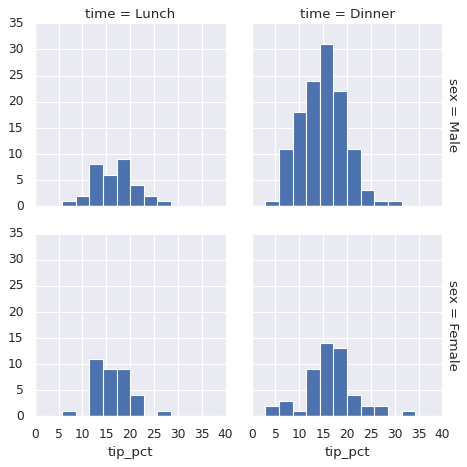

In [ ]:
tips['tip_pct'] = 100 * tips['tip'] / tips['total_bill']
# Вычисляем процент чаевых от общего счета и сохраняем его в новый столбец 'tip_pct'
# Формула: (чаевые / общий счет) * 100
grid = sns.FacetGrid(tips, row="sex", col="time", margin_titles=True)
# Создаем сетку графиков (FacetGrid) для визуализации данных,
# где строки разделены по полу ('sex'), а столбцы — по времени ('time')
# Параметр 'margin_titles' добавляет отступы для заголовков
grid.map(plt.hist, "tip_pct", bins=np.linspace(0, 40, 15));
# Для каждой ячейки сетки строим гистограмму (plt.hist) для столбца 'tip_pct'
# с 15 равномерно распределенными интервалами (bins) от 0 до 40

**Факторные графики**

Факторные графики также могут быть полезны для такого рода визуализации. Это позволяет вам просматривать распределение параметра в пределах интервалов, определенных любым другим параметром:

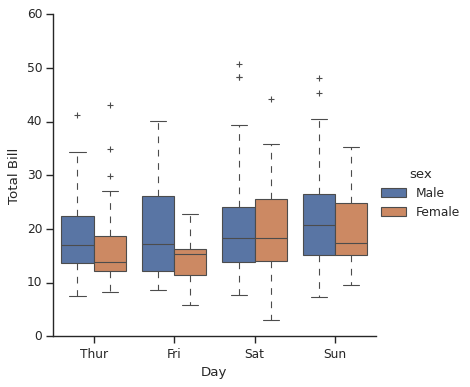

In [ ]:
import seaborn as sns# Импортируем библиотеку Seaborn для визуализации данных
import matplotlib.pyplot as plt# Импортируем библиотеку Matplotlib для построения графиков

# Предполагаем, что набор данных 'tips' уже загружен как DataFrame
with sns.axes_style(style='ticks'):# Устанавливаем стиль графика с помощью Seaborn, выбирая стиль с галочками (ticks)
    g = sns.catplot(x="day", y="total_bill", hue="sex", data=tips, kind="box")
    # Создаем график категориальных данных (catplot) для отображения распределения 'total_bill' по дням ('day')
    # 'hue' используется для разделения данных по полу ('sex'), а 'kind' указывает, что мы хотим построить ящиковый график (box plot)
    g.set_axis_labels("Day", "Total Bill") # Устанавливаем метки для осей X и Y

plt.show()  # Display the plot # Отображаем график на экране

**Совместные распределения**

Подобно парному графику, который мы рассматривали ранее, мы можем использовать его sns.jointplotдля отображения совместного распределения между различными наборами данных, а также связанных с ними предельных распределений:

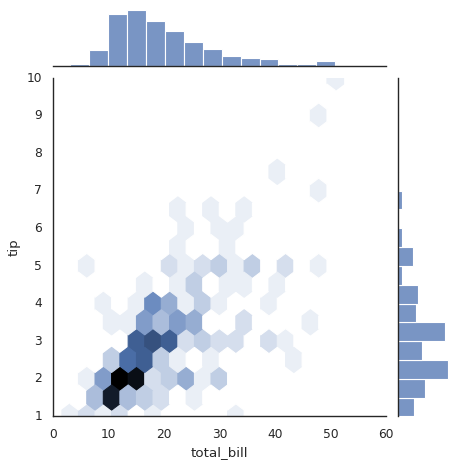

In [ ]:
import seaborn as sns # Импортируем библиотеку Seaborn для визуализации данных
import matplotlib.pyplot as plt# Импортируем библиотеку Matplotlib для построения графиков

# Предполагаем, что набор данных 'tips' уже загружен как DataFrame
with sns.axes_style('white'): # Устанавливаем стиль графика на 'white' (белый фон)
    sns.jointplot(x="total_bill", y="tip", data=tips, kind='hex')
# Создаем график совместного распределения (jointplot) для переменных 'total_bill' (общий счет) и 'tip' (чаевые)
    # Параметр 'kind' установлен на 'hex', что означает использование шестигранной (гексагональной) плотности для отображения значений

plt.show()  # Отображаем график на экране
plt.show()  # Display the plot

Совместный график может даже выполнять некоторую автоматическую оценку плотности ядра и регрессию:

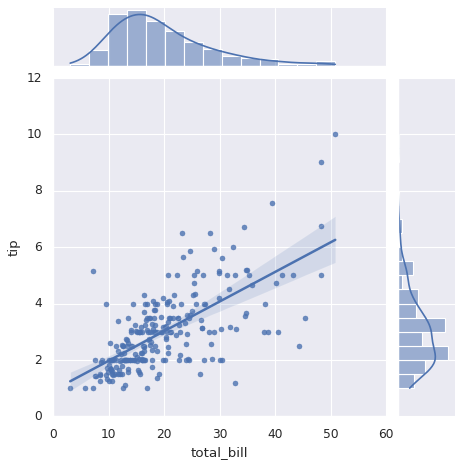

In [ ]:
import seaborn as sns# Импортируем библиотеку Seaborn для визуализации данных
import matplotlib.pyplot as plt# Импортируем библиотеку Matplotlib для построения графиков

# Предполагаем, что набор данных 'tips' уже загружен как DataFrame
sns.jointplot(x="total_bill", y="tip", data=tips, kind='reg')
# Создаем график совместного распределения (jointplot) для переменных 'total_bill' (общий счет) и 'tip' (чаевые)
# Параметр 'kind' установлен на 'reg', что означает, что будет также построена линия регрессии для визуализации зависимости между переменными
plt.show()  # Отображаем график на экране

**Барные диаграммы**

Временные ряды можно построить с помощью sns.factorplot. В следующем примере мы будем использовать данные Planets, которые мы впервые увидели в разделе Агрегация и группировка :

In [ ]:
planets = sns.load_dataset('planets')
planets.head()

,method,number,orbital_period,mass,distance,year
0,Radial Velocity,1,269.300,7.10,77.40,2006
1,Radial Velocity,1,874.774,2.21,56.95,2008
2,Radial Velocity,1,763.000,2.60,19.84,2011
3,Radial Velocity,1,326.030,19.40,110.62,2007
4,Radial Velocity,1,516.220,10.50,119.47,2009


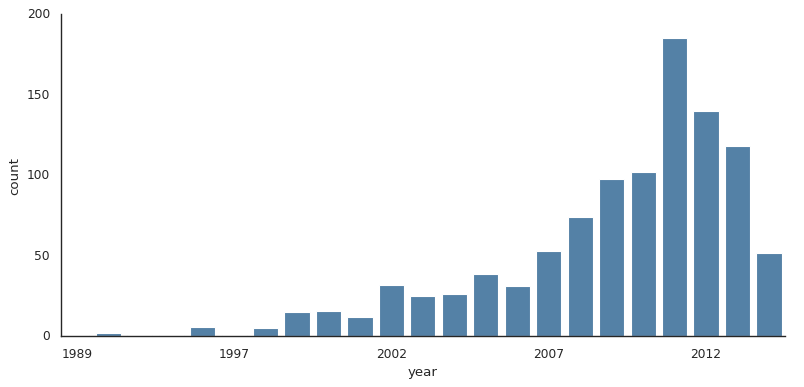

In [ ]:
import seaborn as sns# Импортируем библиотеку Seaborn для визуализации данных
import matplotlib.pyplot as plt# Импортируем библиотеку Matplotlib для построения графиков

# Предполагаем, что набор данных 'planets' уже загружен как DataFrame
with sns.axes_style('white'):# Устанавливаем стиль графика на 'white' (белый фон)
    g = sns.catplot(x="year", data=planets, kind="count", aspect=2, color='steelblue')
 # Создаем график категориальных данных (catplot) для переменной 'year'
    # Параметр 'kind' установлен на 'count', что означает, что мы хотим отобразить количество наблюдений по годам
    # 'aspect' контролирует соотношение сторон графика, а 'color' задает цвет столбцов
# Устанавливаем метки на оси X с шагом 5
plt.xticks(ticks=range(0, len(g.ax.patches), 5))  # Настраиваем метки на оси X, чтобы отображать каждый 5-й год

plt.show()  # Отображаем график на экране

Мы можем узнать больше, рассмотрев метод открытия каждой из этих планет:

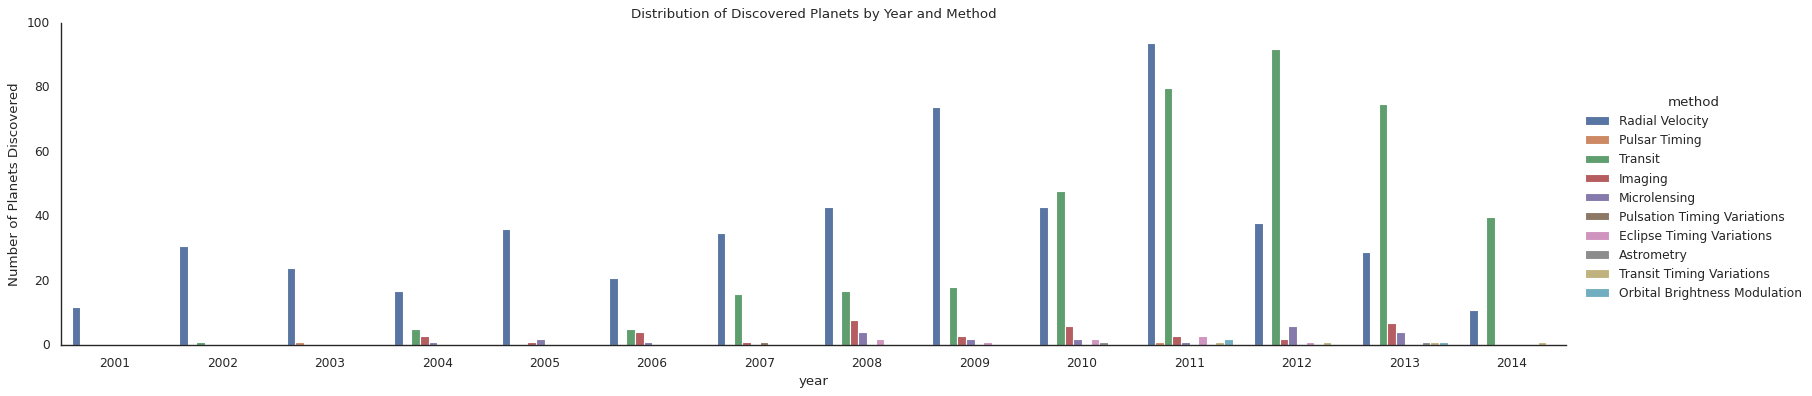

In [ ]:
import seaborn as sns # Импортируем библиотеку Seaborn для визуализации данных
import pandas as pd# Импортируем библиотеку pandas для работы с данными в формате DataFrame
import matplotlib.pyplot as plt # Импортируем библиотеку Matplotlib для построения графиков

# Предположим, что data planets уже загружены
# Пример структуры данных planets:
# planets = pd.DataFrame({
#     'year': [2001, 2002, 2003, ...],
#     'method': ['method1', 'method2', ...]
# })

# Визуализация с использованием catplot
with sns.axes_style('white'): # Устанавливаем стиль графика на 'white' (белый фон)
    g = sns.catplot(x="year", data=planets, aspect=4.0, kind='count',
                    hue='method', order=range(2001, 2015))
     # Создаем график категориальных данных (catplot) для переменной 'year'
    # 'kind' установлен на 'count', чтобы показать количество открытых планет по годам
    # 'hue' используется для разделения данных по методам открытия
    # 'order' задает порядок годов для оси X с 2001 по 2015
    g.set_ylabels('Number of Planets Discovered') # Устанавливаем метку для оси Y

plt.title("Distribution of Discovered Planets by Year and Method") # Устанавливаем заголовок графика
plt.show()  # Отображаем график на экране
plt.show()